In [1]:
from oligo_maldi.experiment import Experiment
from oligo_maldi.oligo import Oligo

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


Load the data into an Experiment object

In [2]:
data = "/Users/mitchsyberg-olsen/github/oligo_maldi/data/experiment_1"
run1 = Experiment(data_folder=data)

With samples loaded, we can already visualize some summary data to begin exploring the experiment

(<Figure size 640x480 with 2 Axes>, <Axes: title={'center': 'total_ion'}>)

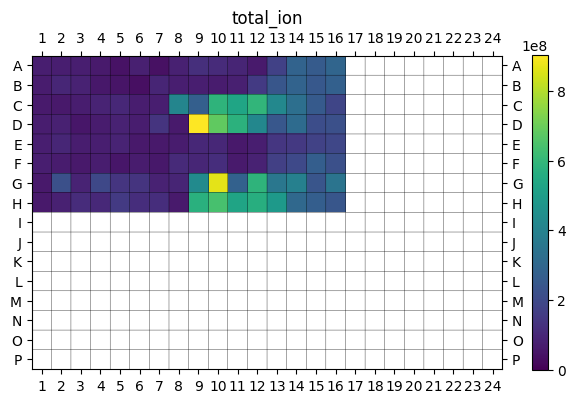

In [3]:
# shows the total signal for each sample in the experiment
run1.heatmap('total_ion')

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Per sample signal intensity distribution'}, xlabel='Percent of data', ylabel='Relative signal'>)

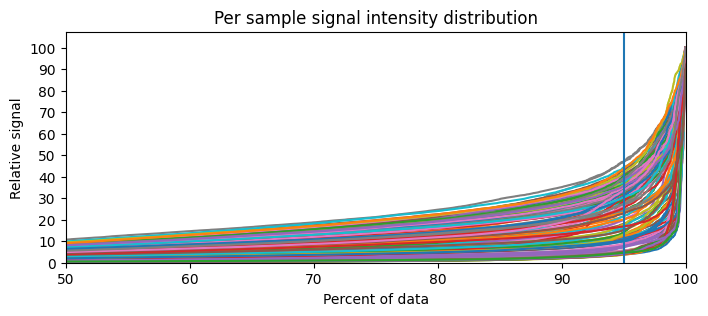

In [4]:
# shows how noisy each sample is
run1.sorted_signal_plot()

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: xlabel='m/z'>], dtype=object))

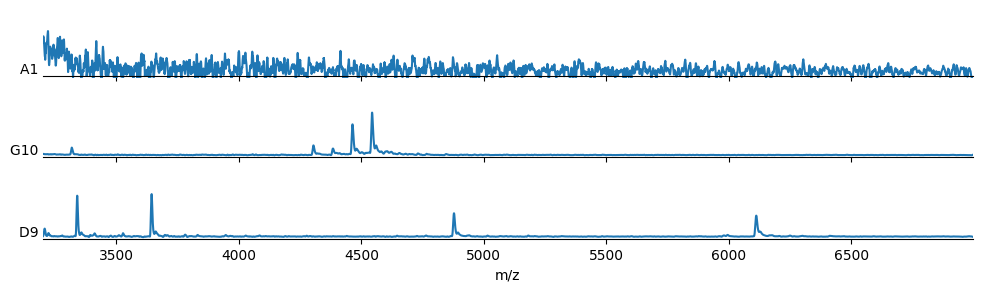

In [5]:
# you can browse 1 or more spectra using Experiment.stacked_plot()
run1.stacked_plot(wells=['A1','G10', 'D9'])

Use the Oligo object to define molecules of interest (MOIs)

In [6]:
# Calibration oligos
MJS296 = Oligo(name='MJS296', seq='ACGTACGTACG', five_prime_end='OH', ps_bonds=0, error=0)
MJS297 = Oligo(name='MJS297', seq='ACGTACGTACGT', five_prime_end='OH', ps_bonds=0, error=0)
MJS392 = Oligo(name='MJS392', seq='ACGTACGTACGTACGT', five_prime_end='OH', ps_bonds=0, error=0)
MJS298 = Oligo(name='MJS298', seq='ACGTACGTACGTACGTACGT', five_prime_end='OH', ps_bonds=0, error=0)
oligos_calibration = [MJS296,MJS297,MJS298,MJS392]

# Experimental oligos
oligo_1H_v1 = 'GGGAGACCACAACG'
v1_starter = [
    Oligo(name=f"Oligo, {end}", seq=oligo_1H_v1, five_prime_end=end) for end in ['OH', 'P', 'PP', 'PPP']
]   # this produces a list of oligos, where each one has the same sequence but a different 5' end chemistry

This section defines which MOIs relate to which samples

In [7]:
# reset mois, necessary when re-running the code to prevent duplicate mois being added to samples
for sample in run1.samples.values():
    sample.mois = []

stds_rows = ['A','B','C','D']
oligo_rows = ['E','F','G','H']

for sample_key in run1.samples.keys():
    if sample_key[0] in stds_rows:
        run1.samples[sample_key].mois.extend(oligos_calibration)
    elif sample_key[0] in oligo_rows:
        run1.samples[sample_key].mois.extend(v1_starter)
    else:
        pass

(<Figure size 640x480 with 2 Axes>, <Axes: title={'center': 'MJS298'}>)

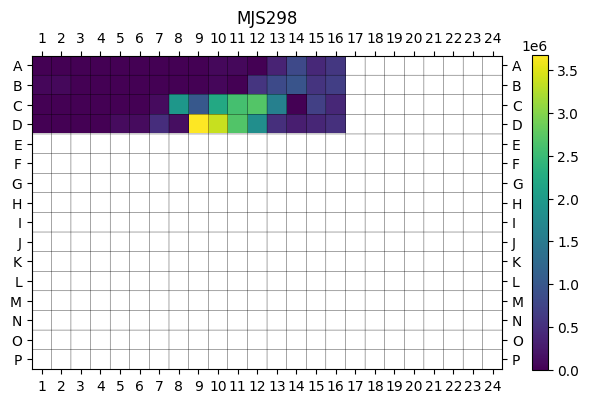

In [8]:
# now we can see where certain MOIs have been defined and how intense their signal is
run1.heatmap('MJS298')

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Oligo, OH / noise'}>)

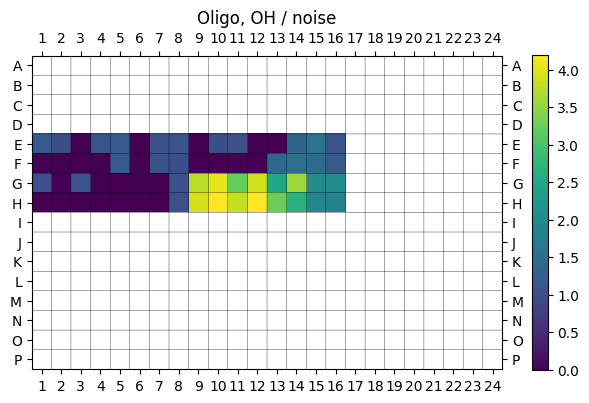

In [9]:
# we can also get the ratio of two different MOIs across samples
run1.heatmap(numerator='Oligo, OH', denominator='noise')

(<Figure size 1200x200 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='m/z'>], dtype=object))

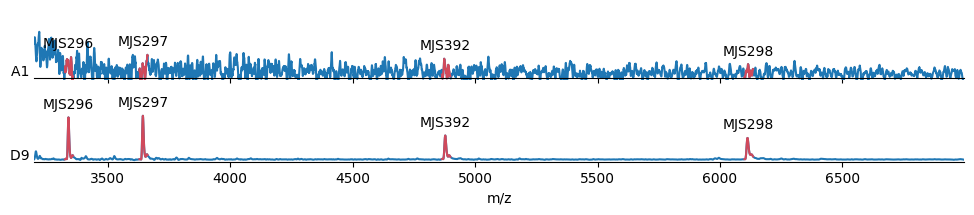

In [10]:
# Experiment.stacked_plot() will now automatically label and highlight MOIs
run1.stacked_plot(wells=['A1', 'D9'], label_first_only=False)

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='m/z'>], dtype=object))

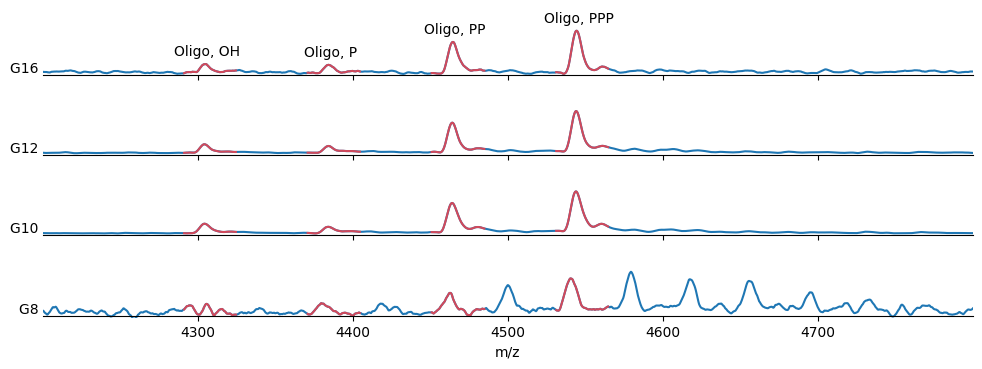

In [11]:
# use xlim to zoom on plots
run1.stacked_plot(wells=['G16', 'G12','G10','G8'], xlim=[4200,4800], label_first_only=True)

(<Figure size 1200x200 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='m/z'>], dtype=object))

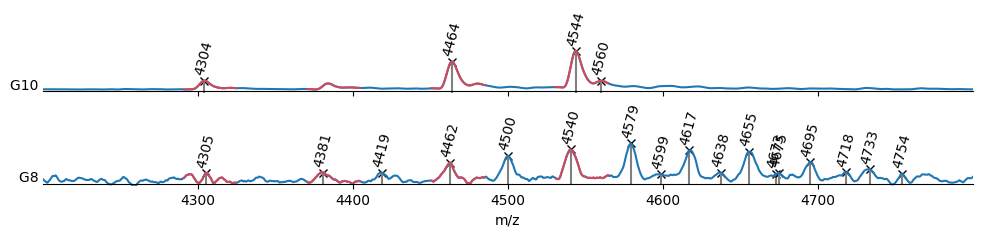

In [12]:
# use label_peaks=True to see the m/z of the peaks in the plot
run1.stacked_plot(wells=['G10','G8'], xlim=[4200,4800], label_peaks=True)

(<Figure size 1200x300 with 1 Axes>, <Axes: xlabel='m/z'>)

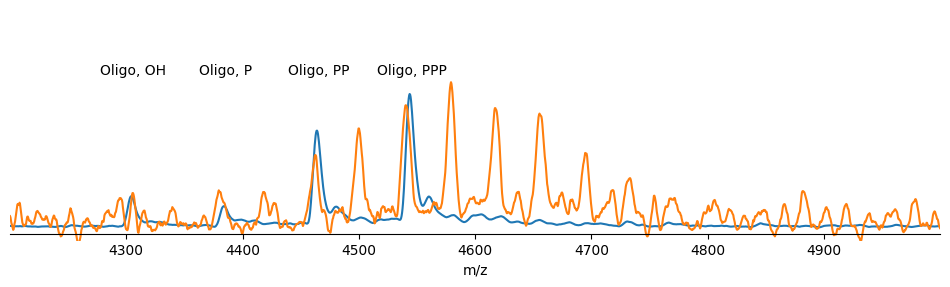

In [13]:
# use overlay=True to stack traces rather than display them separately
run1.stacked_plot(wells=['G10','G8'], xlim=[4200,5000], overlay=True)

Numerical results can be written to an excel file

In [14]:
outfile = "/Users/mitchsyberg-olsen/github/oligo_maldi/demos/experiment_demo_results"
run1.write_to_excel(filename=outfile)